# Task 1: Understand the Business Problem

Before building the model, read the business plan carefully and write a short explanation answering:

- What is the business about?
- What problem is the business trying to solve?
- What decision can machine learning help the business make?
- What is the target variable in the dataset?
- What are the input features?
- Why is this prediction useful for the business?

# Business Problem and Dataset Overview: ReturnWise Retail Analytics

## 1. What is the business about?

ReturnWise Retail Analytics is a decision-support project for a mid-sized e-commerce retailer selling apparel, footwear, electronics, beauty products, home goods, and accessories. The company receives thousands of orders monthly across its website, mobile app, marketplace partners, and social commerce channels. As online sales grow, product returns have become a major operational and financial burden, and the business wants to use data to get ahead of that problem.

## 2. What problem is the business trying to solve?

The core problem is high and costly product return rates. Returns create a cascade of expenses:

- Reverse shipping and logistics costs
- Warehouse inspection and restocking labour
- Refund processing and customer service overhead
- Inventory uncertainty (a "sold" item may reappear in stock weeks later)

Returns happen for many reasons: wrong size, misleading product descriptions, slow delivery, or customers exploiting generous return windows due to heavy discounts. The business wants to identify avoidable returns early, without blaming or penalizing customers unfairly.

## 3. What decision can machine learning help the business make?

ML can help the business answer: "Which orders are at high risk of being returned?"
The goal is not to block or reject orders automatically. Instead, the model supports the decision of which orders deserve proactive intervention, such as:

- Sending improved product guidance or sizing advice before delivery
- Flagging orders for a quality check
- Triggering proactive customer communication about delivery timelines
- Alerting support teams to customers with a history of returns

This shifts the company from reacting to returns after they happen to managing risk before they occur.

## 4. What is the target variable?

| Variable | Prediction | Meaning |
|----------|--------|---------|
| Returned | Yes | The order was returned by the customer |
| Returned | No | The order was not returned |

This is a binary classification problem. The model learns to predict one of two outcomes for each order.

## 5. What are the input features?

The dataset contains five groups of features:

| Feature Group | Example Columns | Business Meaning |
|--------------|----------------|------------------|
| Customer profile | Customer_Age, Customer_Segment, Region | Do return patterns differ by customer type or location? |
| Product information | Product_Category, Product_Price, Product_Rating, Size_Fit_Issue_Level | Which products or categories carry higher return risk? |
| Purchase behaviour | Discount_Percent, Promotion_Type, Purchase_Channel, Payment_Method, Product_Page_Views | Do discounts, channels, or payment methods correlate with returns? |
| Order & delivery | Shipping_Method, Delivery_Time_Days, Items_In_Order, Return_Window_Days | How do operational factors affect return decisions? |
| Customer history | Previous_Orders, Prior_Return_Count, Customer_Support_Contact | Does past behaviour predict future returns? |

## 6. Why is this prediction useful for the business?

A well-trained Decision Tree model turns historical patterns into actionable early warnings. The value is both operational and strategic:

| Model Insight | Possible Business Action |
|--------------|--------------------------|
| High risk linked to size/fit issues | Improve sizing guides, product photos, and descriptions |
| High risk after long delivery times | Provide better delivery estimates and improve customer communication |
| High risk among repeat returners | Offer support, clarify policies, or review for potential misuse |
| Low-rated products linked to returns | Investigate product quality or supplier issues |

By identifying the factors most strongly associated with returns, the business can reduce return rates, improve customer satisfaction, lower operational costs, and make more informed decisions about products, logistics, and customer service.

# Task 2: Prepare the Data

In your notebook, complete the following steps:

- Load the dataset
- Inspect the dataset
- Check the number of rows and columns
- Check data types
- Check missing values
- Check duplicate rows
- Clean the dataset if needed
- Separate features and target variable
- Handle categorical and numerical variables if needed
- Split the data into training and testing sets

In [2]:
# Import pandas library to work with datasets
import pandas as pd

# Import display function to show tables clearly in Jupyter Notebook
from IPython.display import display

# Store the CSV file name in a variable
file_path = "returnwise_product_return_risk_dataset.csv"

# Read the CSV file and load it into a pandas DataFrame
df = pd.read_csv(file_path)

# Print a message to confirm that the dataset has been loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (455, 22)


,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
0,ORD-10116,14/02/2026,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,...,3,6,2,0,4.1,Low,11,No,14,Yes
1,ORD-10179,31/05/2026,30,New Customer,British Columbia,Home & Kitchen,65.04,NaN,No Promotion,Mobile App,...,7,2,2,0,4.1,High,1,No,60,No
2,ORD-10088,14/02/2026,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,...,2,5,1,0,3.6,Low,6,No,30,No
3,ORD-10411,13/03/2026,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,...,2,3,9,0,5.0,Low,4,Yes,60,No
4,ORD-10005,09/05/2026,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,...,3,3,4,0,3.3,High,6,Yes,45,Yes


In [3]:
# Print a title for this output
print("Dataset Shape")

# Print a separator line to make the output clear
print("-" * 50)

# Show the number of rows and columns in the dataset
print(df.shape)

Dataset Shape
--------------------------------------------------
(455, 22)


In [4]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the first five rows of the dataset
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
0,ORD-10116,14/02/2026,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,...,3,6,2,0,4.1,Low,11,No,14,Yes
1,ORD-10179,31/05/2026,30,New Customer,British Columbia,Home & Kitchen,65.04,NaN,No Promotion,Mobile App,...,7,2,2,0,4.1,High,1,No,60,No
2,ORD-10088,14/02/2026,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,...,2,5,1,0,3.6,Low,6,No,30,No
3,ORD-10411,13/03/2026,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,...,2,3,9,0,5.0,Low,4,Yes,60,No
4,ORD-10005,09/05/2026,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,...,3,3,4,0,3.3,High,6,Yes,45,Yes


In [5]:
# Print a title for this output
print("Last Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the last five rows of the dataset
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
450,ORD-10154,31/05/2026,47,Discount Shopper,Prairies,Electronics,459.17,40.0,Percentage Discount,Social Commerce,...,6,3,4,2,2.9,Medium,6,No,30,Yes
451,ORD-10450,23/01/2026,47,Returning Customer,Atlantic Canada,Beauty,370.78,5.0,Bundle Offer,Social Commerce,...,4,5,0,0,3.6,Low,3,No,45,No
452,ORD-10093,21/04/2026,42,Discount Shopper,Ontario,Home & Kitchen,302.28,0.0,No Promotion,Website,...,1,1,4,2,4.0,Low,2,Yes,60,Yes
453,ORD-10337,06/04/2026,35,Returning Customer,Alberta,Electronics,782.32,20.0,Bundle Offer,Marketplace,...,3,2,5,0,3.6,Medium,9,No,14,Yes
454,ORD-10272,30/04/2026,18,Returning Customer,Ontario,Electronics,699.18,25.0,Percentage Discount,Mobile App,...,7,3,5,2,4.7,Low,2,No,30,No


In [6]:
# Print a title for this output
print("Column Names")

# Print a separator line to make the output clear
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['Order_ID', 'Purchase_Date', 'Customer_Age', 'Customer_Segment', 'Region', 'Product_Category', 'Product_Price', 'Discount_Percent', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Size_Fit_Issue_Level', 'Product_Page_Views', 'Customer_Support_Contact', 'Return_Window_Days', 'Returned']


In [7]:
# Print a title for this output
print("Dataset Information")

# Print a separator line to make the output clear
print("-" * 50)

# Show column names, non-null values, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  455 non-null    object 
 1   Purchase_Date             455 non-null    object 
 2   Customer_Age              455 non-null    int64  
 3   Customer_Segment          455 non-null    object 
 4   Region                    448 non-null    object 
 5   Product_Category          455 non-null    object 
 6   Product_Price             449 non-null    float64
 7   Discount_Percent          449 non-null    float64
 8   Promotion_Type            455 non-null    object 
 9   Purchase_Channel          455 non-null    object 
 10  Payment_Method            455 non-null    object 
 11  Shipping_Method           455 non-null    object 
 12  Delivery_Time_Days        455 non-null    int64  

In [8]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Order_ID                     object
Purchase_Date                object
Customer_Age                  int64
Customer_Segment             object
Region                       object
Product_Category             object
Product_Price               float64
Discount_Percent            float64
Promotion_Type               object
Purchase_Channel             object
Payment_Method               object
Shipping_Method              object
Delivery_Time_Days            int64
Items_In_Order                int64
Previous_Orders               int64
Prior_Return_Count            int64
Product_Rating              float64
Size_Fit_Issue_Level         object
Product_Page_Views            int64
Customer_Support_Contact     object
Return_Window_Days            int64
Returned                     object
dtype: object

In [9]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Order_ID                    0
Purchase_Date               0
Customer_Age                0
Customer_Segment            0
Region                      7
Product_Category            0
Product_Price               6
Discount_Percent            6
Promotion_Type              0
Purchase_Channel            0
Payment_Method              0
Shipping_Method             0
Delivery_Time_Days          0
Items_In_Order              0
Previous_Orders             0
Prior_Return_Count          0
Product_Rating              7
Size_Fit_Issue_Level        0
Product_Page_Views          0
Customer_Support_Contact    0
Return_Window_Days          0
Returned                    0
dtype: int64

In [10]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line to make the output clear
print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
5


In [11]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line to make the output clear
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days
count,455.000000,449.000000,449.000000,455.000000,455.000000,455.000000,455.000000,448.000000,455.000000,455.000000
mean,38.272527,215.086214,11.559020,3.586813,2.325275,7.382418,0.938462,3.950670,4.709890,37.232967
std,11.593349,161.537597,12.193445,2.019901,1.406294,7.745605,1.196799,0.641098,2.625571,17.083966
min,18.000000,14.180000,0.000000,0.000000,1.000000,0.000000,0.000000,2.200000,1.000000,14.000000
25%,30.000000,96.800000,0.000000,2.000000,1.000000,1.000000,0.000000,3.500000,2.000000,22.000000
50%,38.000000,173.780000,10.000000,3.000000,2.000000,5.000000,1.000000,3.900000,5.000000,45.000000
75%,46.000000,305.400000,20.000000,5.000000,3.000000,12.000000,1.000000,4.400000,6.500000,45.000000
max,72.000000,824.190000,40.000000,7.000000,6.000000,37.000000,5.000000,5.000000,12.000000,60.000000


# Data Cleaning
Before training a machine learning model, we need to clean the dataset.

In this step, we create a copy of the original dataset and remove duplicate rows.

Duplicate rows can affect the model because repeated records may give extra weight to the same information.

At this stage, we do not handle missing values yet. Missing values will be handled in the next step.

In [12]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (455, 22)
Copied dataset shape: (455, 22)


In [13]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 5


In [14]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [15]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (450, 22)
Number of duplicate rows after cleaning: 0


In [16]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
0,ORD-10116,14/02/2026,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,...,3,6,2,0,4.1,Low,11,No,14,Yes
1,ORD-10179,31/05/2026,30,New Customer,British Columbia,Home & Kitchen,65.04,NaN,No Promotion,Mobile App,...,7,2,2,0,4.1,High,1,No,60,No
2,ORD-10088,14/02/2026,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,...,2,5,1,0,3.6,Low,6,No,30,No
3,ORD-10411,13/03/2026,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,...,2,3,9,0,5.0,Low,4,Yes,60,No
4,ORD-10005,09/05/2026,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,...,3,3,4,0,3.3,High,6,Yes,45,Yes


# Handling Missing Values
In this step, we handle missing values in the cleaned dataset.

Missing values can cause errors during model training, because most machine learning algorithms cannot work with empty cells.

For numerical columns, we fill missing values using the median value of each column.

For categorical columns, we fill missing values using the most frequent value, also called the mode.

This helps us prepare a complete dataset for machine learning.

In [17]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Order_ID                    0
Purchase_Date               0
Customer_Age                0
Customer_Segment            0
Region                      7
Product_Category            0
Product_Price               6
Discount_Percent            6
Promotion_Type              0
Purchase_Channel            0
Payment_Method              0
Shipping_Method             0
Delivery_Time_Days          0
Items_In_Order              0
Previous_Orders             0
Prior_Return_Count          0
Product_Rating              7
Size_Fit_Issue_Level        0
Product_Page_Views          0
Customer_Support_Contact    0
Return_Window_Days          0
Returned                    0
dtype: int64

In [18]:
# Select numerical columns from the cleaned dataset
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the cleaned dataset
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Print numerical columns
print("Numerical columns:")

# Display numerical columns
print(numerical_columns)

# Print a separator line
print("-" * 50)

# Print categorical columns
print("Categorical columns:")

# Display categorical columns
print(categorical_columns)

Numerical columns:
['Customer_Age', 'Product_Price', 'Discount_Percent', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Product_Page_Views', 'Return_Window_Days']
--------------------------------------------------
Categorical columns:
['Order_ID', 'Purchase_Date', 'Customer_Segment', 'Region', 'Product_Category', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Size_Fit_Issue_Level', 'Customer_Support_Contact', 'Returned']


In [19]:
# Loop through each numerical column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical columns have been filled with the median.")

Missing values in numerical columns have been filled with the median.


In [20]:
# Loop through each categorical column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical columns have been filled with the mode.")

Missing values in categorical columns have been filled with the mode.


In [21]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Order_ID                    0
Purchase_Date               0
Customer_Age                0
Customer_Segment            0
Region                      0
Product_Category            0
Product_Price               0
Discount_Percent            0
Promotion_Type              0
Purchase_Channel            0
Payment_Method              0
Shipping_Method             0
Delivery_Time_Days          0
Items_In_Order              0
Previous_Orders             0
Prior_Return_Count          0
Product_Rating              0
Size_Fit_Issue_Level        0
Product_Page_Views          0
Customer_Support_Contact    0
Return_Window_Days          0
Returned                    0
dtype: int64

In [22]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (450, 22)


,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
0,ORD-10116,14/02/2026,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,...,3,6,2,0,4.1,Low,11,No,14,Yes
1,ORD-10179,31/05/2026,30,New Customer,British Columbia,Home & Kitchen,65.04,10.0,No Promotion,Mobile App,...,7,2,2,0,4.1,High,1,No,60,No
2,ORD-10088,14/02/2026,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,...,2,5,1,0,3.6,Low,6,No,30,No
3,ORD-10411,13/03/2026,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,...,2,3,9,0,5.0,Low,4,Yes,60,No
4,ORD-10005,09/05/2026,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,...,3,3,4,0,3.3,High,6,Yes,45,Yes


# Understanding Features and Target Variable
In this step, we identify the input features and the target variable of the dataset.

The target variable is the column that we want the machine learning model to predict.

In this dataset, the target variable is Returned. 

The features are the columns that help the model make the prediction.

In [23]:
# Store the target column name in a variable
target_column = "Returned"

# Print the target variable name
print("Target variable:")

# Display the target column name
print(target_column)

Target variable:
Returned


In [24]:
# Print a title for the target values
print("Target variable values:")

# Print a separator line
print("-" * 50)

# Display the unique values in the target column
print(df_clean[target_column].unique())

Target variable values:
--------------------------------------------------
['Yes' 'No']


In [25]:
# Print a title for the target class distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Count how many customers are in each target class
target_counts = df_clean[target_column].value_counts()

# Display the target class counts
display(target_counts)

Target class distribution:
--------------------------------------------------


Returned
No     315
Yes    135
Name: count, dtype: int64

In [26]:
# Create a list of feature columns by removing the target column and Lead_ID column
feature_columns = df_clean.drop(columns=[target_column, "Order_ID", "Purchase_Date"]).columns.tolist()

# Print a title for the feature columns
print("Feature columns:")

# Print a separator line
print("-" * 50)

# Display the feature columns
print(feature_columns)

Feature columns:
--------------------------------------------------
['Customer_Age', 'Customer_Segment', 'Region', 'Product_Category', 'Product_Price', 'Discount_Percent', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Size_Fit_Issue_Level', 'Product_Page_Views', 'Customer_Support_Contact', 'Return_Window_Days']


# Handling Categorical and Numerical Variables
In this step, we identify numerical and categorical variables in the dataset.

This step is important because machine learning models need numerical input.

Later, we will convert categorical variables into numerical format during preprocessing.

In [27]:
# Select numerical columns from the cleaned dataset
numerical_features = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print a title for numerical features
print("Numerical feature columns:")

# Print a separator line
print("-" * 50)

# Display numerical feature columns
print(numerical_features)

Numerical feature columns:
--------------------------------------------------
['Customer_Age', 'Product_Price', 'Discount_Percent', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Product_Page_Views', 'Return_Window_Days']


In [28]:
# Select categorical columns from the cleaned dataset
categorical_features = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Remove the target column from categorical features if it is included
if target_column in categorical_features:
    categorical_features.remove(target_column)  

# Remove Order_ID 
if "Order_ID" in categorical_features:
    categorical_features.remove("Order_ID")

# Remove Purchase_Date 
if "Purchase_Date" in categorical_features:
    categorical_features.remove("Purchase_Date")
 
# Print a title for categorical features
print("Categorical feature columns:")

# Print a separator line
print("-" * 50)

# Display categorical feature columns
print(categorical_features)

Categorical feature columns:
--------------------------------------------------
['Customer_Segment', 'Region', 'Product_Category', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Size_Fit_Issue_Level', 'Customer_Support_Contact']


In [29]:
# Count the number of numerical features
num_count = len(numerical_features)

# Count the number of categorical features
cat_count = len(categorical_features)

# Print the number of numerical features
print("Number of numerical features:", num_count)

# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 10
Number of categorical features: 9


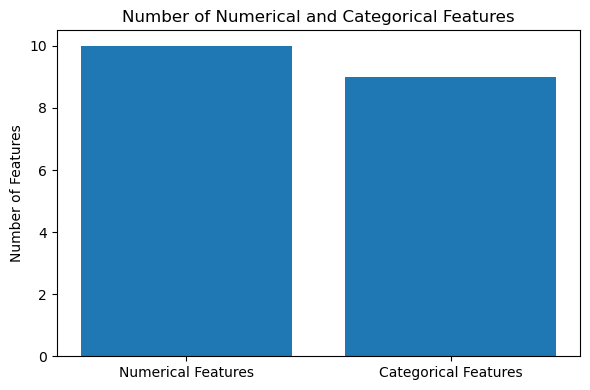

In [30]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart
feature_type_counts = [num_count, cat_count]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [31]:
# Print a title for unique values
print("Unique values in categorical features")

# Print a separator line
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: Customer_Segment
['New Customer' 'Returning Customer' 'VIP Customer' 'Discount Shopper']
--------------------------------------------------
Column: Region
['British Columbia' 'Atlantic Canada' 'Ontario' 'Alberta' 'Quebec'
 'Prairies']
--------------------------------------------------
Column: Product_Category
['Beauty' 'Home & Kitchen' 'Apparel' 'Footwear' 'Electronics'
 'Accessories']
--------------------------------------------------
Column: Promotion_Type
['No Promotion' 'Percentage Discount' 'Bundle Offer' 'Free Shipping']
--------------------------------------------------
Column: Purchase_Channel
['Mobile App' 'Website' 'Marketplace' 'Social Commerce']
--------------------------------------------------
Column: Payment_Method
['Credit Card' 'Buy Now Pay Later' 'PayPal' 'Debit Card']
--------------------------------------------------
Column: Shipping_Method
['Express' 'Standard' 'Same-Da

In [32]:
# Count unique values for each categorical feature
categorical_unique_counts = df_clean[categorical_features].nunique()

# Print a title
print("Number of unique values in each categorical feature:")

# Print a separator line
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of unique values in each categorical feature:
--------------------------------------------------


Customer_Segment            4
Region                      6
Product_Category            6
Promotion_Type              4
Purchase_Channel            4
Payment_Method              4
Shipping_Method             3
Size_Fit_Issue_Level        3
Customer_Support_Contact    2
dtype: int64

## Short Interpretation
The dataset contains both numerical and categorical features.

Numerical features can be used directly by many machine learning models, while categorical features must be converted into numerical format before training.

In the next steps, we will define X and y, split the data into training and testing sets, and then apply preprocessing to prepare the data for Decision Tree model.

# Defining X and y
In this step, we define the input features and the target variable for the machine learning model.

The input features are stored in X. These are the columns that the model uses to make predictions.

The target variable is stored in y. This is the column that the model tries to predict.

In [33]:
# Define the name of the target column
target_column = "Returned"

# Print the target column name
print("Target column:")

# Display the target column
print(target_column)

Target column:
Returned


In [34]:
# Create X by removing the target column from the dataset
X = df_clean.drop(columns=[target_column, "Order_ID", "Purchase_Date"])

# Create y by selecting only the target column
y = df_clean[target_column]

# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.")

X and y have been defined successfully.


In [35]:
# Print the shape of X
print("Shape of X:")

# Display the number of rows and columns in X
print(X.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y
print("Shape of y:")

# Display the number of rows in y
print(y.shape)

Shape of X:
(450, 19)
--------------------------------------------------
Shape of y:
(450,)


In [36]:
# Print a title for X
print("First five rows of X:")

# Print a separator line
print("-" * 50)

# Display the first five rows of X
display(X.head())

First five rows of X:
--------------------------------------------------


,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,Payment_Method,Shipping_Method,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days
0,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,Credit Card,Express,3,6,2,0,4.1,Low,11,No,14
1,30,New Customer,British Columbia,Home & Kitchen,65.04,10.0,No Promotion,Mobile App,Credit Card,Standard,7,2,2,0,4.1,High,1,No,60
2,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,Buy Now Pay Later,Express,2,5,1,0,3.6,Low,6,No,30
3,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,PayPal,Express,2,3,9,0,5.0,Low,4,Yes,60
4,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,Buy Now Pay Later,Standard,3,3,4,0,3.3,High,6,Yes,45


In [37]:
# Print a title for y
print("First five values of y:")

# Print a separator line
print("-" * 50)

# Display the first five values of y
display(y.head())

First five values of y:
--------------------------------------------------


0    Yes
1     No
2     No
3     No
4    Yes
Name: Returned, dtype: object

In [38]:
# Count how many times each target class appears
target_distribution = y.value_counts()

# Print a title for the target distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Display the target class distribution
display(target_distribution)

Target class distribution:
--------------------------------------------------


Returned
No     315
Yes    135
Name: count, dtype: int64

# Train/Test Split
In this step, we will split the dataset into training and testing sets.

The training set is used to teach the machine learning model.

The testing set is used to evaluate how well the model performs on new, unseen data.

In this notebook, we use 80% of the data for training and 20% of the data for testing.

We also use stratify=y to keep the same proportion of Yes and No values in both training and testing sets.

In [39]:
# Import train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

In [40]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    
    # Use X as the input features
    X,
    
    # Use y as the target variable
    y,
    
    # Use 20% of the data for testing
    test_size=0.2,
    
    # Keep the same target class distribution in train and test sets
    stratify=y,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.")

Data has been split into training and testing sets.


In [41]:
# Print the shape of X_train
print("X_train shape:")

# Display the number of rows and columns in X_train
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of X_test
print("X_test shape:")

# Display the number of rows and columns in X_test
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_train
print("y_train shape:")

# Display the number of target values in y_train
print(y_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_test
print("y_test shape:")

# Display the number of target values in y_test
print(y_test.shape)

X_train shape:
(360, 19)
--------------------------------------------------
X_test shape:
(90, 19)
--------------------------------------------------
y_train shape:
(360,)
--------------------------------------------------
y_test shape:
(90,)


In [42]:
# Print a title for the training target distribution
print("Target distribution in training set:")

# Print a separator line
print("-" * 50)

# Count the number of Yes and No values in y_train
train_distribution = y_train.value_counts()

# Display the target distribution in the training set
display(train_distribution)

Target distribution in training set:
--------------------------------------------------


Returned
No     252
Yes    108
Name: count, dtype: int64

In [43]:
# Print a title for the testing target distribution
print("Target distribution in testing set:")

# Print a separator line
print("-" * 50)

# Count the number of Yes and No values in y_test
test_distribution = y_test.value_counts()

# Display the target distribution in the testing set
display(test_distribution)

Target distribution in testing set:
--------------------------------------------------


Returned
No     63
Yes    27
Name: count, dtype: int64

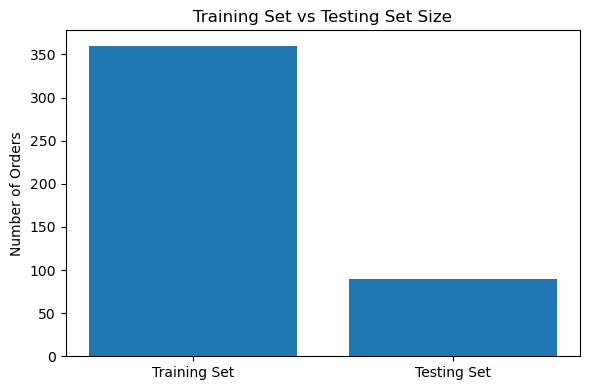

In [44]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Orders")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## Short Interpretation
The dataset has now been divided into training and testing sets.

The training set will be used to train the Decision Tree model.

The testing set will be used to evaluate the models and compare their performance.

In the next step, we will preprocess the data so that categorical variables can be used by machine learning models.

# Preprocessing the Data
In this step, we preprocess the data before training machine learning models.

Machine learning models cannot directly work with categorical text values.

Therefore, we convert categorical variables into numerical format using One-Hot Encoding.

For Decision Tree model, feature scaling is usually not required because these models split the data based on decision rules.

We fit the preprocessing only on the training data and then apply it to the testing data. This helps prevent data leakage.

In [45]:
# Import ColumnTransformer to apply different preprocessing steps to different columns
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder to convert categorical variables into numerical columns
from sklearn.preprocessing import OneHotEncoder

In [46]:
# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print numerical features
print("Numerical features:")
print(numerical_features)

# Print a separator line
print("-" * 50)

# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Customer_Age', 'Product_Price', 'Discount_Percent', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Product_Page_Views', 'Return_Window_Days']
--------------------------------------------------
Categorical features:
['Customer_Segment', 'Region', 'Product_Category', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Size_Fit_Issue_Level', 'Customer_Support_Contact']


In [47]:
# Create a one-hot encoder for categorical variables
# handle_unknown="ignore" prevents errors if new categories appear in the test set
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    
    # Define the transformations
    transformers=[
        
        # Apply one-hot encoding to categorical features
        ("categorical", encoder, categorical_features),
        
        # Keep numerical features unchanged
        ("numerical", "passthrough", numerical_features)
    ]
)

# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [48]:
# Fit the preprocessor on the training data and transform X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Print a message to confirm preprocessing is complete
print("Training and testing data have been preprocessed successfully.")

Training and testing data have been preprocessed successfully.


In [49]:
# Print the shape of the original X_train
print("Original X_train shape:")
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_train
print("Processed X_train shape:")
print(X_train_processed.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the original X_test
print("Original X_test shape:")
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_test
print("Processed X_test shape:")
print(X_test_processed.shape)

Original X_train shape:
(360, 19)
--------------------------------------------------
Processed X_train shape:
(360, 46)
--------------------------------------------------
Original X_test shape:
(90, 19)
--------------------------------------------------
Processed X_test shape:
(90, 46)


In [50]:
# Get the new feature names created from categorical variables
encoded_categorical_features = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)

# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_features) + numerical_features

# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))

# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names)

Number of processed features: 46
--------------------------------------------------
['Customer_Segment_Discount Shopper', 'Customer_Segment_New Customer', 'Customer_Segment_Returning Customer', 'Customer_Segment_VIP Customer', 'Region_Alberta', 'Region_Atlantic Canada', 'Region_British Columbia', 'Region_Ontario', 'Region_Prairies', 'Region_Quebec', 'Product_Category_Accessories', 'Product_Category_Apparel', 'Product_Category_Beauty', 'Product_Category_Electronics', 'Product_Category_Footwear', 'Product_Category_Home & Kitchen', 'Promotion_Type_Bundle Offer', 'Promotion_Type_Free Shipping', 'Promotion_Type_No Promotion', 'Promotion_Type_Percentage Discount', 'Purchase_Channel_Marketplace', 'Purchase_Channel_Mobile App', 'Purchase_Channel_Social Commerce', 'Purchase_Channel_Website', 'Payment_Method_Buy Now Pay Later', 'Payment_Method_Credit Card', 'Payment_Method_Debit Card', 'Payment_Method_PayPal', 'Shipping_Method_Express', 'Shipping_Method_Same-Day', 'Shipping_Method_Standard', 'Si

In [51]:
# Convert processed training data into a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

# Convert processed testing data into a DataFrame
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

# Display the first five rows of the processed training data
display(X_train_processed_df.head())

,Customer_Segment_Discount Shopper,Customer_Segment_New Customer,Customer_Segment_Returning Customer,Customer_Segment_VIP Customer,Region_Alberta,Region_Atlantic Canada,Region_British Columbia,Region_Ontario,Region_Prairies,Region_Quebec,...,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days
444,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,34.0,204.00,0.0,6.0,2.0,17.0,1.0,3.6,6.0,60.0
191,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,31.0,341.30,5.0,6.0,5.0,19.0,5.0,5.0,7.0,14.0
91,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,46.0,319.11,0.0,1.0,1.0,12.0,0.0,4.0,5.0,30.0
199,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,48.0,195.24,25.0,3.0,4.0,0.0,0.0,3.8,7.0,45.0
392,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,44.0,119.27,10.0,6.0,2.0,9.0,3.0,4.5,3.0,45.0


## Short Interpretation
The categorical features have now been converted into numerical format using One-Hot Encoding.

The numerical features were kept unchanged because Decision Tree model do not usually require feature scaling.

Now the dataset is ready for training tree-based machine learning models.

# Task 3: Train a Decision Tree Classification Model

Train one classification model:

- Decision Tree

After training the model, calculate the following:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score

You should also calculate:

- Training accuracy
- Testing accuracy

Then briefly explain whether the Decision Tree model may be overfitting.

In [52]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

In [53]:
# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
    
    # Limit the depth of the tree to make it easier to understand
    max_depth=4,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [54]:
# Train the Decision Tree model using the preprocessed training data
decision_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Decision Tree model has been trained successfully.")

Decision Tree model has been trained successfully.


In [55]:
# Print the model information
print("Decision Tree Model Information")

# Print a separator line
print("-" * 50)

# Display the trained model
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


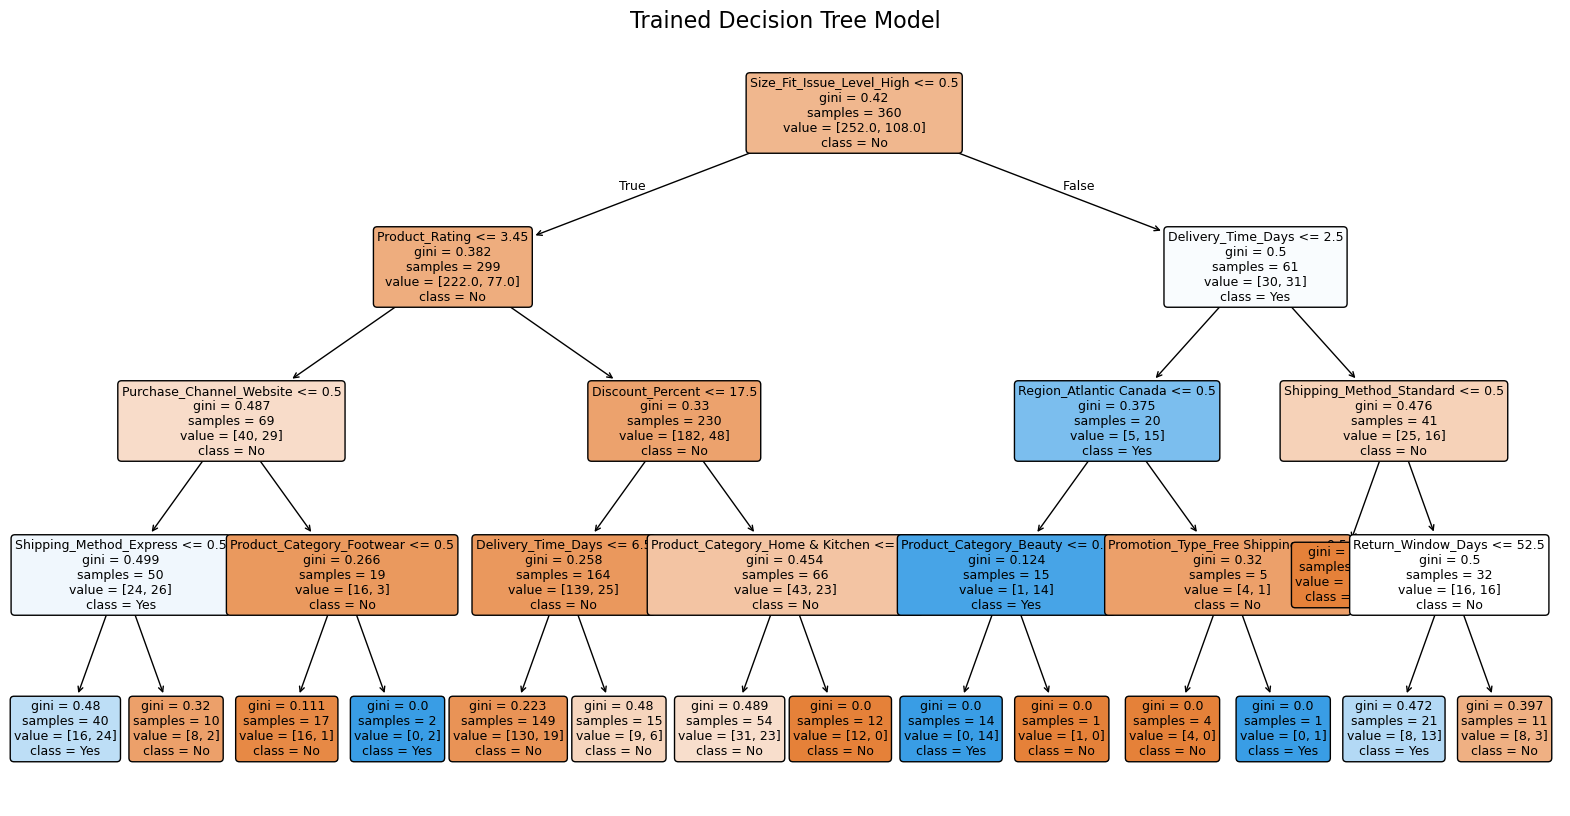

In [56]:
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

# Import plot_tree to visualize the Decision Tree
from sklearn.tree import plot_tree

# Create a large figure for the tree visualization
plt.figure(figsize=(20, 10))

# Plot the trained Decision Tree
plot_tree(
    
    # Use the trained Decision Tree model
    decision_tree_model,
    
    # Use feature names from the processed training data
    feature_names=X_train_processed_df.columns,
    
    # Show class names from the target variable
    class_names=decision_tree_model.classes_,
    
    # Fill the tree boxes to make the classes easier to distinguish
    filled=True,
    
    # Round the corners of the boxes
    rounded=True,
    
    # Set the font size
    fontsize=9
)

# Add a title to the figure
plt.title("Trained Decision Tree Model", fontsize=16)

# Display the figure
plt.show()

In [57]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()

# Print the depth of the tree
print("Decision Tree depth:", tree_depth)

# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 15


# Evaluating the Decision Tree Model
After training the Decision Tree model, we need to evaluate its performance.

In this step, we use the trained Decision Tree model to make predictions on the testing set.

We also compare the predicted values with the actual values to see how the model performs.

In [58]:
# Use the trained Decision Tree model to predict the target values for the testing data
y_pred_dt = decision_tree_model.predict(X_test_processed_df)

# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [59]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
    
    # Store the actual values from the testing set
    "Actual": y_test.values,
    
    # Store the predicted values from the Decision Tree model
    "Predicted": y_pred_dt
})

# Print a title for the output
print("Actual vs Predicted Values")

# Print a separator line
print("-" * 50)

# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,Yes,No
1,No,No
2,No,No
3,Yes,No
4,No,No
5,Yes,No
6,Yes,Yes
7,No,No
8,No,No
9,No,No


In [60]:
# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")

# Display the accuracy value
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.6666666666666666


In [61]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)

# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.7833333333333333
Decision Tree Testing Accuracy: 0.6666666666666666


In [62]:
# Create a small table to compare training and testing accuracy
dt_accuracy_table = pd.DataFrame({
    
    # Store model evaluation type
    "Evaluation Set": ["Training Set", "Testing Set"],
    
    # Store accuracy values
    "Accuracy": [dt_train_accuracy, dt_test_accuracy]
})

# Display the accuracy comparison table
display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.783333
1,Testing Set,0.666667


In [63]:
# Count actual class values in the testing set
actual_counts = y_test.value_counts()

# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_pred_dt).value_counts()

# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
    
    # Store actual class counts
    "Actual": actual_counts,
    
    # Store predicted class counts
    "Predicted": predicted_counts
})

# Fill any missing values with zero
class_count_comparison = class_count_comparison.fillna(0)

# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
No,63,79
Yes,27,11


<Figure size 700x400 with 0 Axes>

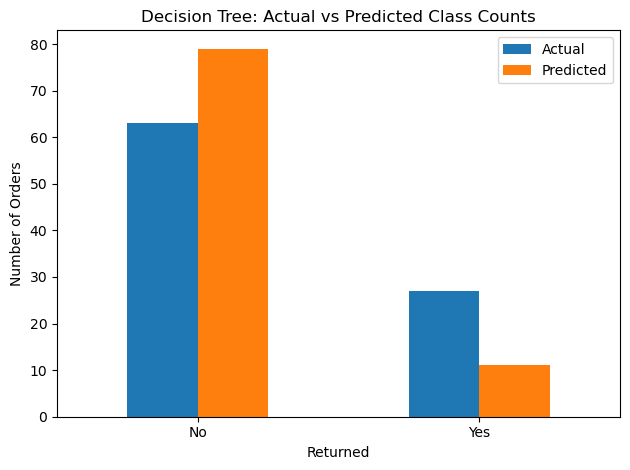

In [64]:
# Create a figure for actual vs predicted class counts
plt.figure(figsize=(7, 4))

# Create a bar chart for actual and predicted class counts
class_count_comparison.plot(kind="bar")

# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")

# Add a label to the x-axis
plt.xlabel("Returned")

# Add a label to the y-axis
plt.ylabel("Number of Orders")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

# Confusion Matrix for Decision Tree
In this step, we use a confusion matrix to evaluate the Decision Tree model in more detail.

A confusion matrix shows how many predictions were correct and how many were incorrect.

The target variable is Returned, with two classes: Yes and No.

In [65]:
# Import confusion_matrix to calculate the confusion matrix
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

In [66]:
# Define the class labels in a fixed order
class_labels = ["No", "Yes"]

# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

# Print a title for the output
print("Decision Tree Confusion Matrix")

# Print a separator line
print("-" * 50)

# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[56  7]
 [23  4]]


In [67]:
# Create a DataFrame to show the confusion matrix in a readable table format
cm_dt_table = pd.DataFrame(
    
    # Use the confusion matrix values
    cm_dt,
    
    # Set row labels as actual classes
    index=["Actual No", "Actual Yes"],
    
    # Set column labels as predicted classes
    columns=["Predicted No", "Predicted Yes"]
)

# Display the confusion matrix table
display(cm_dt_table)

,Predicted No,Predicted Yes
Actual No,56,7
Actual Yes,23,4


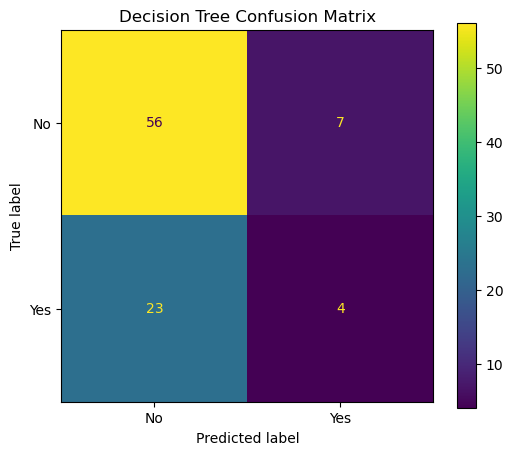

In [68]:
# Create a figure for the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
    
    # Use the Decision Tree confusion matrix
    confusion_matrix=cm_dt,
    
    # Use class labels for display
    display_labels=class_labels
)

# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")

# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")

# Display the figure
plt.show()

In [69]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()

# Print True Negative value
print("True Negative:", tn)

# Print False Positive value
print("False Positive:", fp)

# Print False Negative value
print("False Negative:", fn)

# Print True Positive value
print("True Positive:", tp)

True Negative: 56
False Positive: 7
False Negative: 23
True Positive: 4


In [70]:
# Create a table to explain each part of the confusion matrix
confusion_explanation = pd.DataFrame({
    
    # Name of each confusion matrix component
    "Component": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    
    # Meaning of each component in this business problem
    "Meaning": [
        "Order was not returned, and the model predicted Not Returned",
        "Order was not returned, but the model predicted Returned",
        "Order was returned, but the model predicted Not Returned",
        "Order was returned, and the model predicted Returned"
    ],

     # Business impact of each prediction result
    "Business Impact": [
        "The model correctly identified a low-risk order, avoiding unnecessary intervention.",
        "The company may spend time or resources on unnecessary support, guidance, or quality checks for an order that would not have been returned.",
        "The company misses an opportunity to identify and prepare for a return, potentially increasing return-related costs and operational workload.",
        "The model correctly identified a high-risk order, allowing the business to take preventive actions such as improved customer guidance, quality checks, or proactive support."
],
    
    # Store the calculated values
    "Value": [tn, fp, fn, tp]
})

# Display the explanation table
display(confusion_explanation)

,Component,Meaning,Business Impact,Value
0,True Negative,"Order was not returned, and the model predicte...",The model correctly identified a low-risk orde...,56
1,False Positive,"Order was not returned, but the model predicte...",The company may spend time or resources on unn...,7
2,False Negative,"Order was returned, but the model predicted No...",The company misses an opportunity to identify ...,23
3,True Positive,"Order was returned, and the model predicted Re...",The model correctly identified a high-risk ord...,4


# Accuracy, Precision, Recall, and F1-Score
In this step, we calculate four important evaluation metrics for the Decision Tree model.

These metrics help us understand model performance more clearly than accuracy alone.

- Accuracy shows the overall percentage of correct predictions.
- Precision measures how many orders predicted as returned were actually returned.
- Recall measures how many actual returned orders were correctly identified by the model.
- F1-score combines precision and recall into one balanced score.

In this business problem, these metrics help evaluate how effectively the model identifies orders that are likely to be returned. The results can support decisions about proactive customer guidance, quality checks, inventory planning, and customer support aimed at reducing avoidable return costs.

In [71]:
# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score

# Import precision_score to calculate precision
from sklearn.metrics import precision_score

# Import recall_score to calculate recall
from sklearn.metrics import recall_score

# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score

# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [72]:
# Calculate the accuracy of the Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the accuracy score
print("Decision Tree Accuracy:")

# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.6666666666666666


In [73]:
# Calculate precision for the positive class, which is "Yes"
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the precision score
print("Decision Tree Precision:")

# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.36363636363636365


In [74]:
# Calculate recall for the positive class, which is "Yes"
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the recall score
print("Decision Tree Recall:")

# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.14814814814814814


In [75]:
# Calculate F1-score for the positive class, which is "Yes"
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the F1-score
print("Decision Tree F1-Score:")

# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.21052631578947367


In [76]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({
    
    # Store the metric names
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    
    # Store the metric values
    "Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]
})

# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.666667
1,Precision,0.363636
2,Recall,0.148148
3,F1-Score,0.210526


In [77]:
# Print a title for the classification report
print("Decision Tree Classification Report")

# Print a separator line
print("-" * 50)

# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.71      0.89      0.79        63
         Yes       0.36      0.15      0.21        27

    accuracy                           0.67        90
   macro avg       0.54      0.52      0.50        90
weighted avg       0.61      0.67      0.62        90



# Understanding Overfitting in Decision Trees
Overfitting happens when a machine learning model learns the training data too well.

In a Decision Tree, overfitting can happen when the tree becomes too deep and creates too many rules.

When this happens, the model may perform very well on the training data but poorly on the testing data.

This means the model memorizes the training data instead of learning general patterns.

In this step, we compare a controlled Decision Tree with an overfitted Decision Tree.

In [78]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
    
    # Allow the tree to grow as much as possible
    max_depth=None,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [79]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)

# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)

# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.6


In [80]:
# Predict the target values for the training data using the controlled Decision Tree
y_train_pred_controlled = decision_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the controlled Decision Tree
y_test_pred_controlled = decision_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store the training accuracy values
    "Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
    
    # Store the testing accuracy values
    "Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]
})

# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.783333,0.666667
1,Overfitted Decision Tree,1.000000,0.600000


<Figure size 800x500 with 0 Axes>

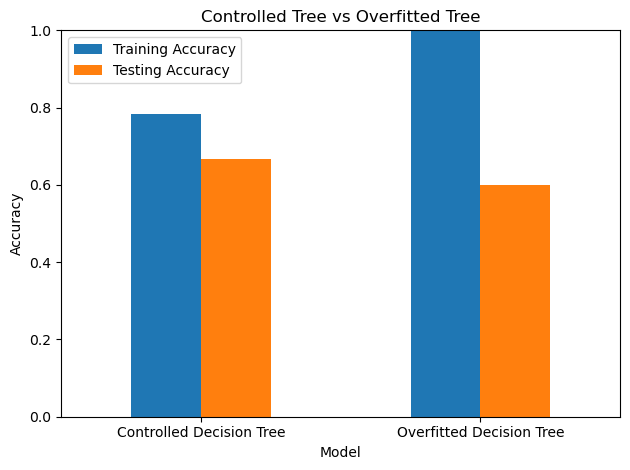

In [81]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the chart
plt.show()

In [82]:
# Get the depth of the controlled Decision Tree
controlled_tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the controlled Decision Tree
controlled_tree_leaves = decision_tree_model.get_n_leaves()

# Get the depth of the overfitted Decision Tree
overfit_tree_depth = overfit_tree_model.get_depth()

# Get the number of leaf nodes in the overfitted Decision Tree
overfit_tree_leaves = overfit_tree_model.get_n_leaves()

# Create a table to compare tree complexity
tree_complexity_table = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store tree depth values
    "Tree Depth": [controlled_tree_depth, overfit_tree_depth],
    
    # Store number of leaf nodes
    "Number of Leaves": [controlled_tree_leaves, overfit_tree_leaves]
})

# Display the tree complexity table
display(tree_complexity_table)

,Model,Tree Depth,Number of Leaves
0,Controlled Decision Tree,4,15
1,Overfitted Decision Tree,14,73


# Controlling Decision Tree Complexity
Decision Trees can become too complex if they are allowed to grow without limits.

A very deep tree may memorize the training data instead of learning general patterns.

To reduce overfitting, we can control the complexity of the Decision Tree using parameters such as:

- max_depth
- min_samples_split
- min_samples_leaf

In this step, we compare Decision Trees with different maximum depths and observe how training and testing accuracy change.

In [83]:
# Import DecisionTreeClassifier to create Decision Tree models
from sklearn.tree import DecisionTreeClassifier

# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score

# Import pandas to create comparison tables
import pandas as pd

# Import matplotlib to create charts
import matplotlib.pyplot as plt

In [84]:
# Create an empty list to store the results
depth_results = []

# Create a list of different max_depth values to test
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Loop through each depth value
for depth in depth_values:
    
    # Create a Decision Tree model with the current max_depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train the model using the processed training data
    model.fit(X_train_processed_df, y_train)
    
    # Predict the target values for the training data
    y_train_pred = model.predict(X_train_processed_df)
    
    # Predict the target values for the testing data
    y_test_pred = model.predict(X_test_processed_df)
    
    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Store the depth, training accuracy, and testing accuracy
    depth_results.append([depth, train_accuracy, test_accuracy])

# Convert the results into a DataFrame
depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

# Display the results table
display(depth_results_df)

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.702778,0.633333
1,2,0.727778,0.655556
2,3,0.741667,0.655556
3,4,0.783333,0.666667
4,5,0.844444,0.677778
5,6,0.877778,0.655556
6,7,0.902778,0.688889
7,8,0.925000,0.644444
8,9,0.950000,0.633333
9,10,0.969444,0.588889


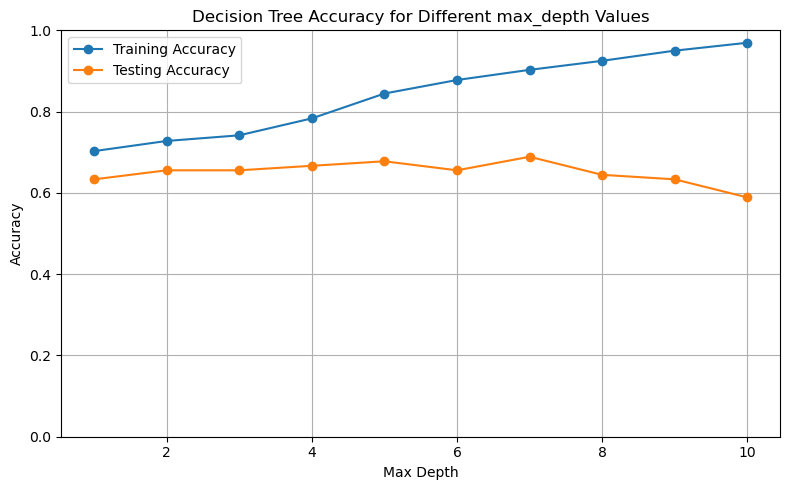

In [85]:
# Create a figure for the line chart
plt.figure(figsize=(8, 5))

# Plot training accuracy for each max_depth value
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")

# Plot testing accuracy for each max_depth value
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")

# Add a title to the chart
plt.title("Decision Tree Accuracy for Different max_depth Values")

# Add a label to the x-axis
plt.xlabel("Max Depth")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Add a legend to explain the lines
plt.legend()

# Add grid lines to make the chart easier to read
plt.grid(True)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [86]:
# Create a controlled Decision Tree model
controlled_tree_model = DecisionTreeClassifier(
    
    # Limit the maximum depth of the tree
    max_depth=4,
    
    # Require at least 5 samples in each leaf node
    min_samples_leaf=5,
    
    # Use a fixed random state for reproducible results
    random_state=42
)

# Train the controlled Decision Tree model
controlled_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the controlled model has been trained
print("Controlled Decision Tree model has been trained successfully.")

Controlled Decision Tree model has been trained successfully.


In [87]:
# Predict the target values for the training data
y_train_pred_controlled = controlled_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data
y_test_pred_controlled = controlled_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the controlled tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Print the training accuracy
print("Controlled Decision Tree Training Accuracy:", controlled_train_accuracy)

# Print the testing accuracy
print("Controlled Decision Tree Testing Accuracy:", controlled_test_accuracy)

Controlled Decision Tree Training Accuracy: 0.7722222222222223
Controlled Decision Tree Testing Accuracy: 0.6666666666666666


In [88]:
# Calculate training accuracy for the original Decision Tree model
original_train_accuracy = accuracy_score(y_train, decision_tree_model.predict(X_train_processed_df))

# Calculate testing accuracy for the original Decision Tree model
original_test_accuracy = accuracy_score(y_test, decision_tree_model.predict(X_test_processed_df))

# Create a comparison table
tree_control_comparison = pd.DataFrame({
    
    # Store model names
    "Model": ["Original Decision Tree", "Controlled Decision Tree"],
    
    # Store training accuracy values
    "Training Accuracy": [original_train_accuracy, controlled_train_accuracy],
    
    # Store testing accuracy values
    "Testing Accuracy": [original_test_accuracy, controlled_test_accuracy]
})

# Display the comparison table
display(tree_control_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,0.783333,0.666667
1,Controlled Decision Tree,0.772222,0.666667


<Figure size 800x500 with 0 Axes>

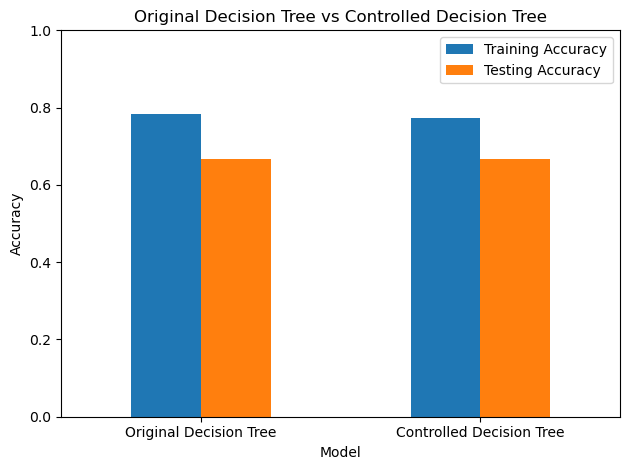

In [89]:
# Set the model column as the index for plotting
tree_control_plot = tree_control_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
tree_control_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Original Decision Tree vs Controlled Decision Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels to keep them readable
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [90]:
# Get the depth of the original Decision Tree
original_depth = decision_tree_model.get_depth()

# Get the number of leaves in the original Decision Tree
original_leaves = decision_tree_model.get_n_leaves()

# Get the depth of the controlled Decision Tree
controlled_depth = controlled_tree_model.get_depth()

# Get the number of leaves in the controlled Decision Tree
controlled_leaves = controlled_tree_model.get_n_leaves()

# Create a table to compare tree complexity
complexity_comparison = pd.DataFrame({
    
    # Store model names
    "Model": ["Original Decision Tree", "Controlled Decision Tree"],
    
    # Store tree depth values
    "Tree Depth": [original_depth, controlled_depth],
    
    # Store number of leaves
    "Number of Leaves": [original_leaves, controlled_leaves]
})

# Display the complexity comparison table
display(complexity_comparison)

,Model,Tree Depth,Number of Leaves
0,Original Decision Tree,4,15
1,Controlled Decision Tree,4,14


# Feature Importance in Tree-Based Models
Tree-based models can show which features are most important for making predictions.

Feature importance helps us understand which variables had the strongest influence on the model's decision.

In this business problem, feature importance helps identify which customer, product, purchase, delivery, and historical factors are most strongly associated with product returns.

For example, important features may include product category, product rating, size-fit issue level, delivery time, discount percentage, prior return count, and customer support contacts.

In this step, we calculate feature importance for the Decision Tree model to better understand the key drivers of return risk and provide insights that can support business decisions aimed at reducing avoidable returns.

In [91]:
# Print a title for the output
print("Processed Feature Names")

# Print a separator line
print("-" * 50)

# Show the number of processed features after one-hot encoding
print("Number of processed features:", len(X_train_processed_df.columns))

# Display the processed feature names
print(X_train_processed_df.columns.tolist())

Processed Feature Names
--------------------------------------------------
Number of processed features: 46
['Customer_Segment_Discount Shopper', 'Customer_Segment_New Customer', 'Customer_Segment_Returning Customer', 'Customer_Segment_VIP Customer', 'Region_Alberta', 'Region_Atlantic Canada', 'Region_British Columbia', 'Region_Ontario', 'Region_Prairies', 'Region_Quebec', 'Product_Category_Accessories', 'Product_Category_Apparel', 'Product_Category_Beauty', 'Product_Category_Electronics', 'Product_Category_Footwear', 'Product_Category_Home & Kitchen', 'Promotion_Type_Bundle Offer', 'Promotion_Type_Free Shipping', 'Promotion_Type_No Promotion', 'Promotion_Type_Percentage Discount', 'Purchase_Channel_Marketplace', 'Purchase_Channel_Mobile App', 'Purchase_Channel_Social Commerce', 'Purchase_Channel_Website', 'Payment_Method_Buy Now Pay Later', 'Payment_Method_Credit Card', 'Payment_Method_Debit Card', 'Payment_Method_PayPal', 'Shipping_Method_Express', 'Shipping_Method_Same-Day', 'Shippi

In [92]:
# Get feature importance values from the trained Decision Tree model
dt_feature_importance_values = decision_tree_model.feature_importances_

# Create a DataFrame for Decision Tree feature importance
dt_feature_importance = pd.DataFrame({
    
    # Store feature names
    "Feature": X_train_processed_df.columns,
    
    # Store Decision Tree importance values
    "Importance": dt_feature_importance_values
})

# Sort the features from most important to least important
dt_feature_importance = dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Reset the index after sorting
dt_feature_importance = dt_feature_importance.reset_index(drop=True)

# Print a title for the output
print("Decision Tree Feature Importance")

# Display the top 10 most important features
display(dt_feature_importance.head(10))

Decision Tree Feature Importance


,Feature,Importance
0,Size_Fit_Issue_Level_High,0.138754
1,Delivery_Time_Days,0.119930
2,Product_Rating,0.103574
3,Region_Atlantic Canada,0.087896
4,Discount_Percent,0.078834
5,Purchase_Channel_Website,0.078683
6,Product_Category_Home & Kitchen,0.077631
7,Shipping_Method_Standard,0.076539
8,Product_Category_Footwear,0.069088
9,Shipping_Method_Express,0.055789


In [93]:
# Select the most important feature from the Decision Tree model
dt_most_important_feature = dt_feature_importance.iloc[0]["Feature"]

# Select the importance value of the most important Decision Tree feature
dt_most_important_value = dt_feature_importance.iloc[0]["Importance"]

# Print the most important Decision Tree feature
print("Most important feature in Decision Tree:", dt_most_important_feature)

# Print its importance value
print("Decision Tree importance value:", dt_most_important_value)

Most important feature in Decision Tree: Size_Fit_Issue_Level_High
Decision Tree importance value: 0.1387537459217788


In [94]:
# Create a short summary table for feature importance results
feature_importance_summary = pd.DataFrame({
    
    # Store model names
    "Model": ["Decision Tree"],
    
    # Store the most important feature for each model
    "Most Important Feature": [dt_most_important_feature],
    
    # Store the importance value for each model
    "Importance Value": [dt_most_important_value]
})

# Display the summary table
display(feature_importance_summary)

,Model,Most Important Feature,Importance Value
0,Decision Tree,Size_Fit_Issue_Level_High,0.138754


# Visualizing Feature Importance
In this step, we visualize the most important features used by the Decision Tree model.

A higher importance score means that the feature contributed more to the model's decision-making process.

This step is useful for both model interpretation and business decision-making.

In [95]:
# Select the top 10 most important features from the Decision Tree model
dt_top_features = dt_feature_importance.head(10)

# Print a title for the output
print("Top 10 Decision Tree Features")

# Print a separator line
print("-" * 50)

# Display the top 10 Decision Tree features
display(dt_top_features)

Top 10 Decision Tree Features
--------------------------------------------------


,Feature,Importance
0,Size_Fit_Issue_Level_High,0.138754
1,Delivery_Time_Days,0.119930
2,Product_Rating,0.103574
3,Region_Atlantic Canada,0.087896
4,Discount_Percent,0.078834
5,Purchase_Channel_Website,0.078683
6,Product_Category_Home & Kitchen,0.077631
7,Shipping_Method_Standard,0.076539
8,Product_Category_Footwear,0.069088
9,Shipping_Method_Express,0.055789


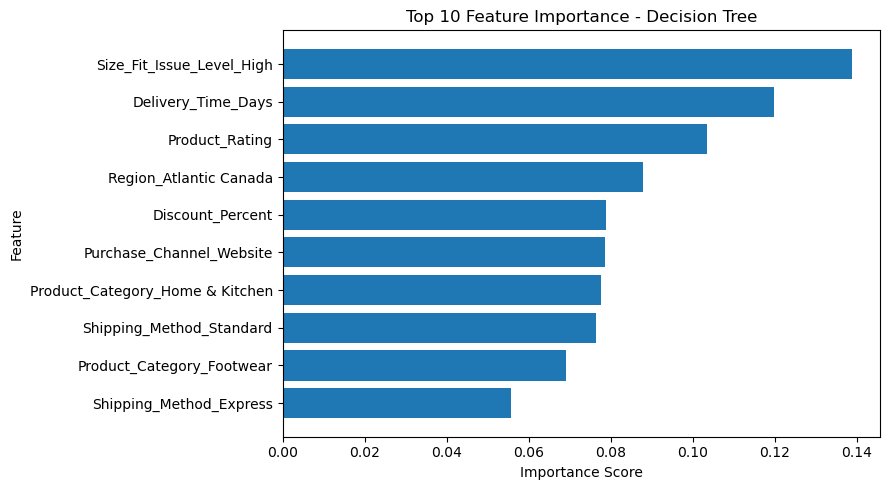

In [96]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Sort the top Decision Tree features in ascending order for better horizontal visualization
dt_top_features_plot = dt_top_features.sort_values(by="Importance", ascending=True)

# Create a figure for the Decision Tree feature importance chart
plt.figure(figsize=(9, 5))

# Create a horizontal bar chart for Decision Tree feature importance
plt.barh(dt_top_features_plot["Feature"], dt_top_features_plot["Importance"])

# Add a title to the chart
plt.title("Top 10 Feature Importance - Decision Tree")

# Add a label to the x-axis
plt.xlabel("Importance Score")

# Add a label to the y-axis
plt.ylabel("Feature")

# Adjust the layout to prevent labels from being cut off
plt.tight_layout()

# Display the chart
plt.show()